## Importing the Important Libraries

In [ ]:
import os 
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.autograd as autograd
from collections import deque, namedtuple
import gymnasium as gym
import warnings
warnings.filterwarnings("ignore")

## Environment Setups

In [6]:
env = gym.make("LunarLander-v3", continuous=False, gravity=-10.0,
               enable_wind=False, wind_power=15.0, turbulence_power=1.5)

In [8]:
state = env.observation_space.shape
state_size = env.observation_space.shape[0]
action_size = env.action_space.n

print(state, state_size, action_size)

(8,) 8 4


## Defining the Hyperparameter for the agent

In [9]:
learning_rate = 5e-4
minibatch = 150
gamma = 0.99
replay_buffer_size = 100,000
interpolation_parameter = 1e-3
number_episodes = 5000
max_time_steps = 1000
epsilon_starting_value = 1.0
epsilon_ending_value = 0.01
epsilon_decay_value = 0.995
scores_100_episodes = deque(maxlen=100)

## Defining the Neural Networks

In [10]:
class ANN(nn.Module):
        def __init(self, state_size, action_size, seed =42):
                super(ANN, self).__init__()
                self.seed = torch.manual_seed(seed)
                self.fc1 = nn.Linear(state_size, 64)
                self.fc2 = nn.Linear(64, 64)
                self.fc3 = nn.Linear(64, action_size)

                def forward(self, state):
                        x = self.fc1(state)
                        x = F.relu(x)
                        x = self.fc2(x)
                        x = F.relu(x)
                        return self.fc3(x)

## ReplayMemory: 
- The ReplayMemory class is designed to manage the agent's memory of game experiences. It stores the state, action, reward, next state, and whether the episode ended(done) for each step in the game.

         experience = (state, action, reward, next_state, done)

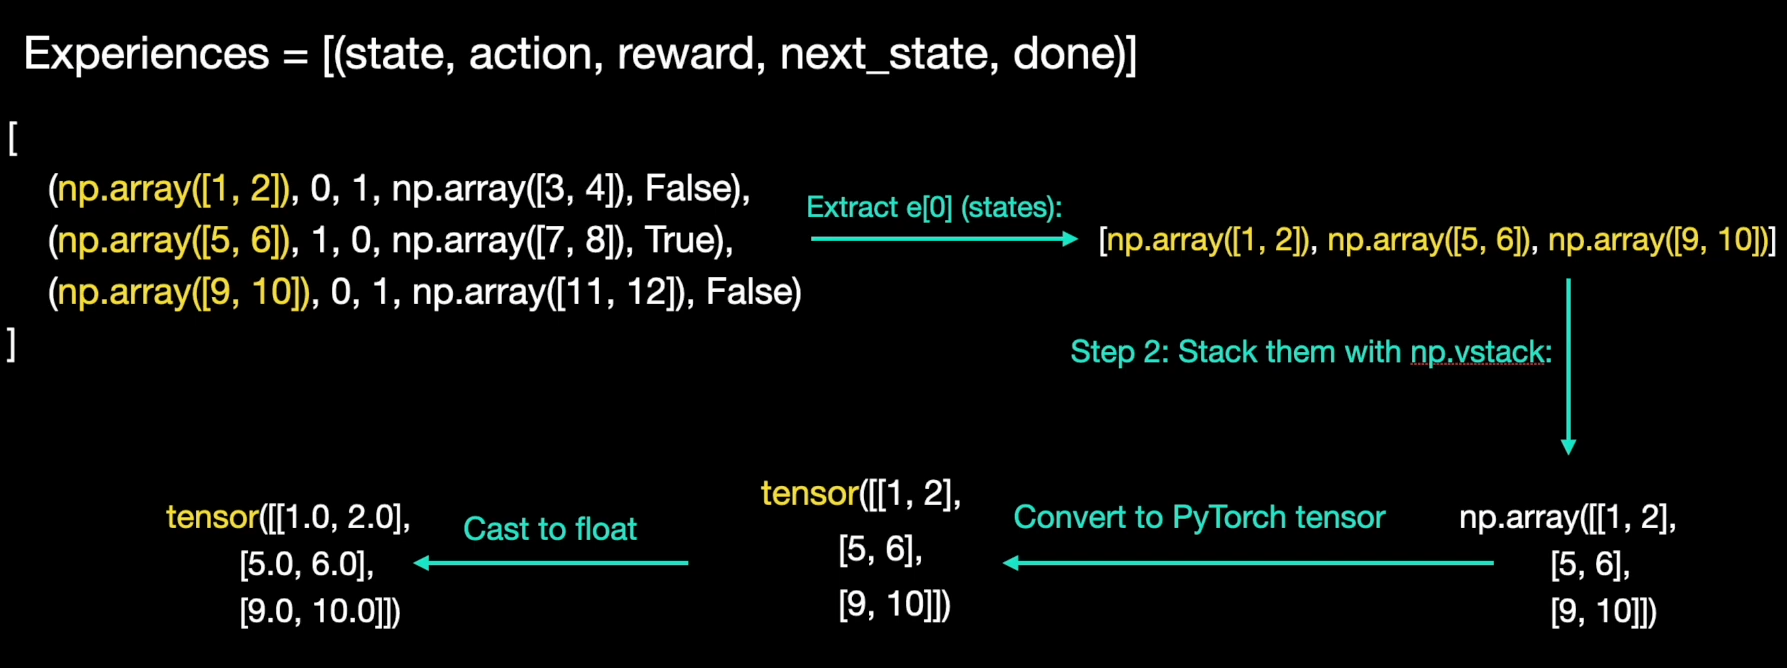

In [11]:
class ReplayMemory(object):

        def __init__(self, capacity):
                self.capacity = capacity
                self.memory = []

        
        def push(self, event):
                self.memory.append(event)
                if len(self.memory) > self.capacity:
                        del self.memory[0]

        
        def sample(self, batch_size):
                experiences = random.sample(self.memory, batch_size)
                states = torch.from_numpy(np.vstack([e[0] for e in experiences if e is not None])).float()
                actions = torch.from_numpy(np.vstack([e[1] for e in experiences if e is not None])).long()
                rewards = torch.from_numpy(np.vstack([e[2] for e in experiences if e is not None])).float()
                next_state = torch.from_numpy(np.vstack([e[3] for e in experiences if e is not None])).float()
                dones = torch.from_numpy(np.vstack([e[4] for e in experiences if e is not None]).astype(np.unit8)).float()

                return states, actions, rewards, next_states, dones

## Defining the RL Agent

- ## Local Vs Target Q-Network
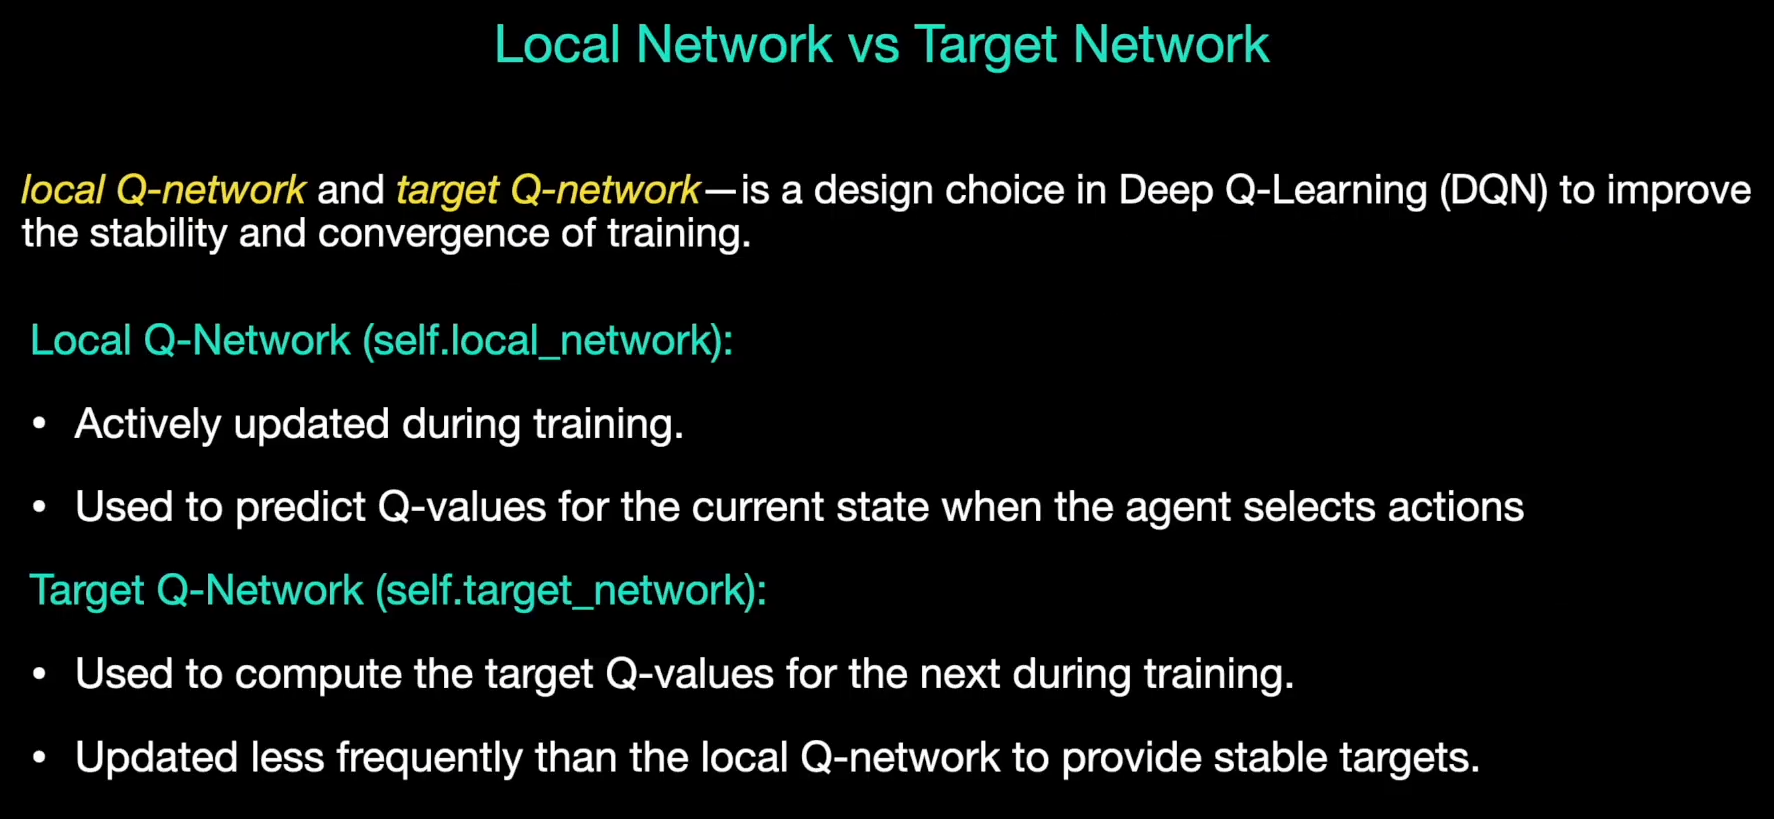

- ## Exploration Vs Exploitation Tradeoffs
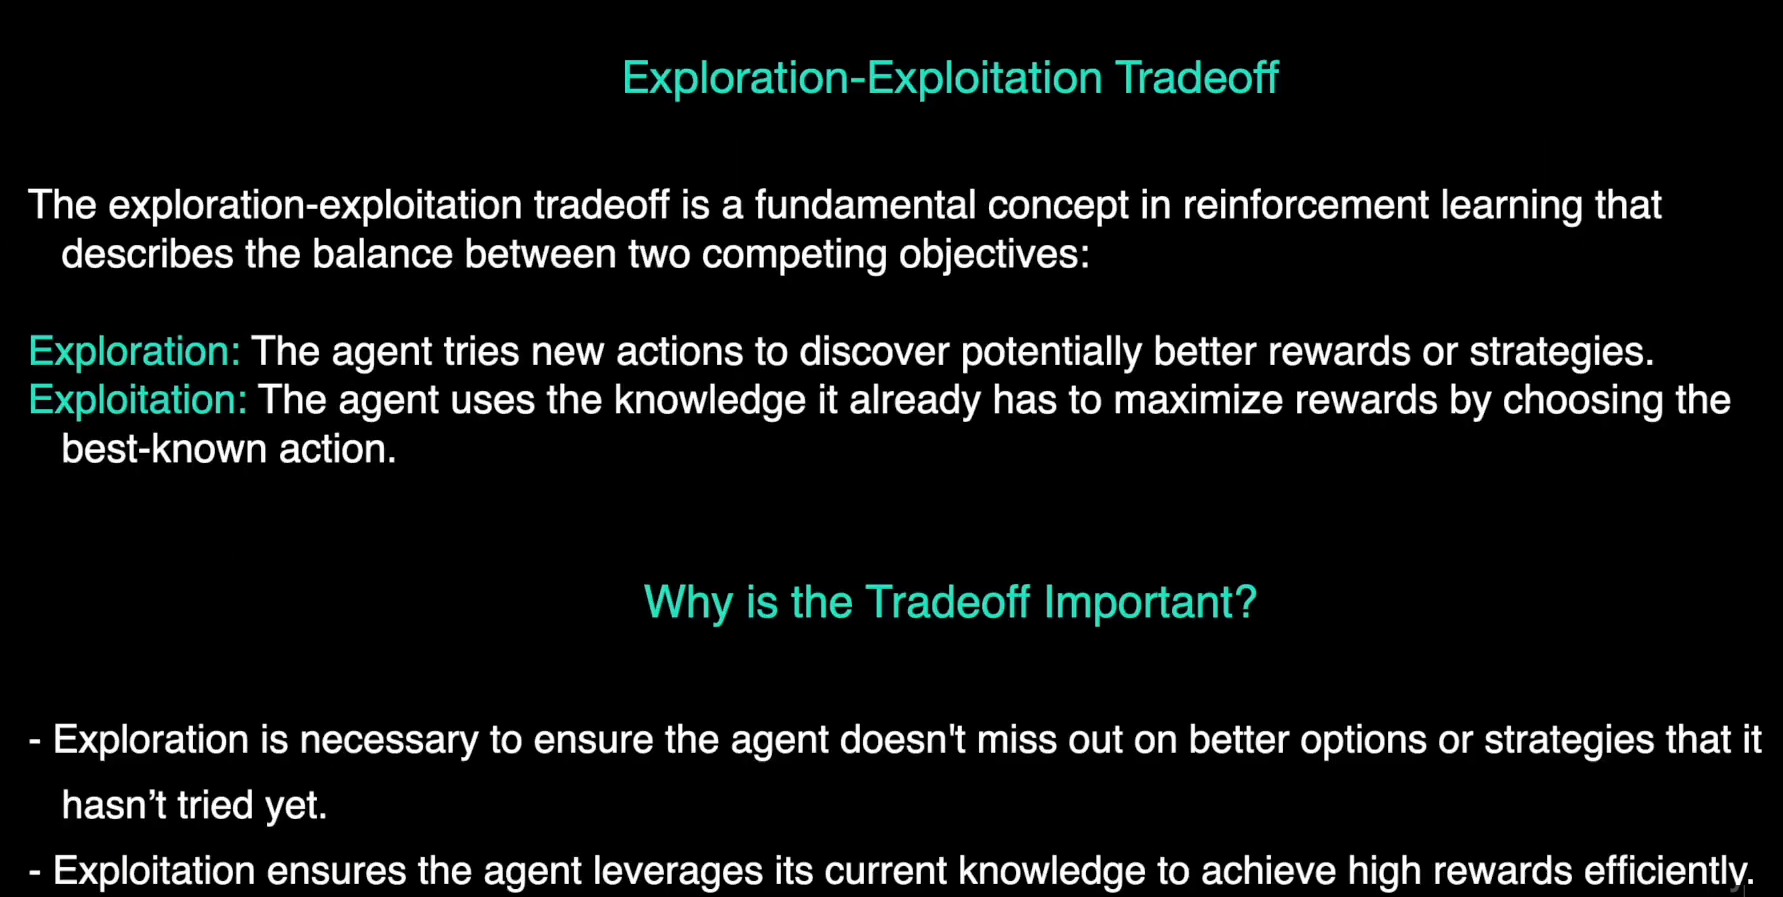

- ## Bellmen Equation
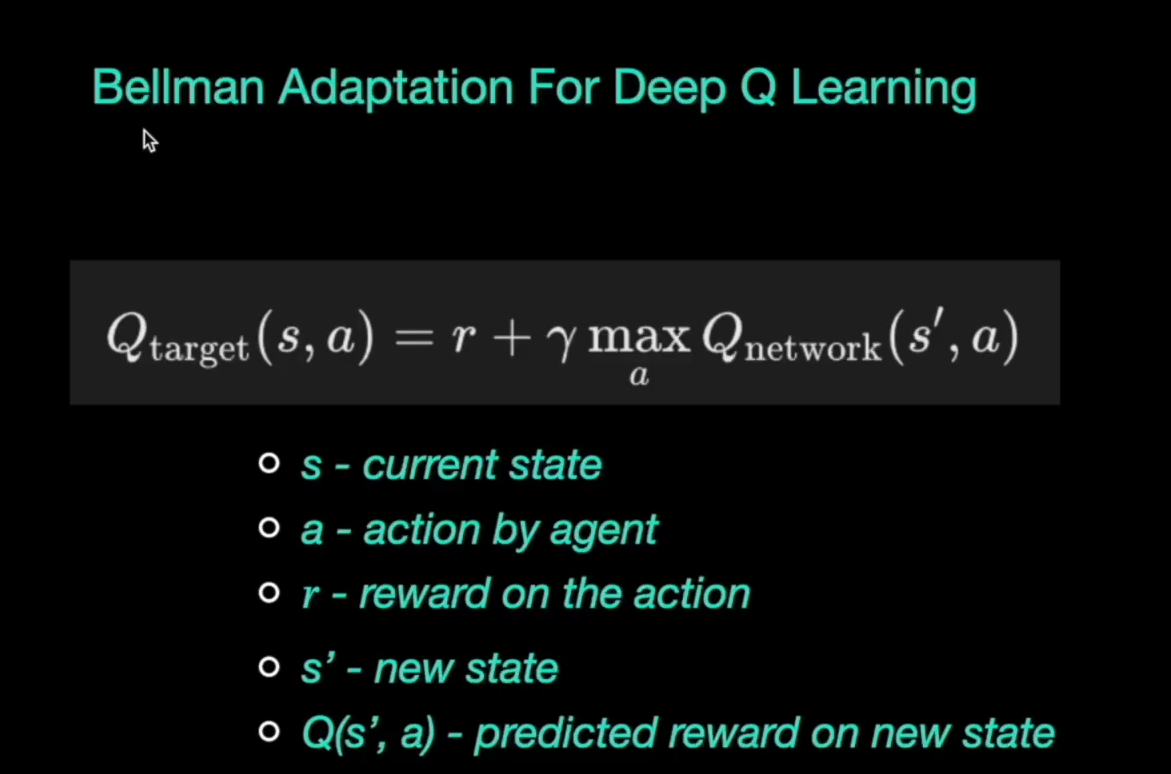

- ## Next-Q-Target State
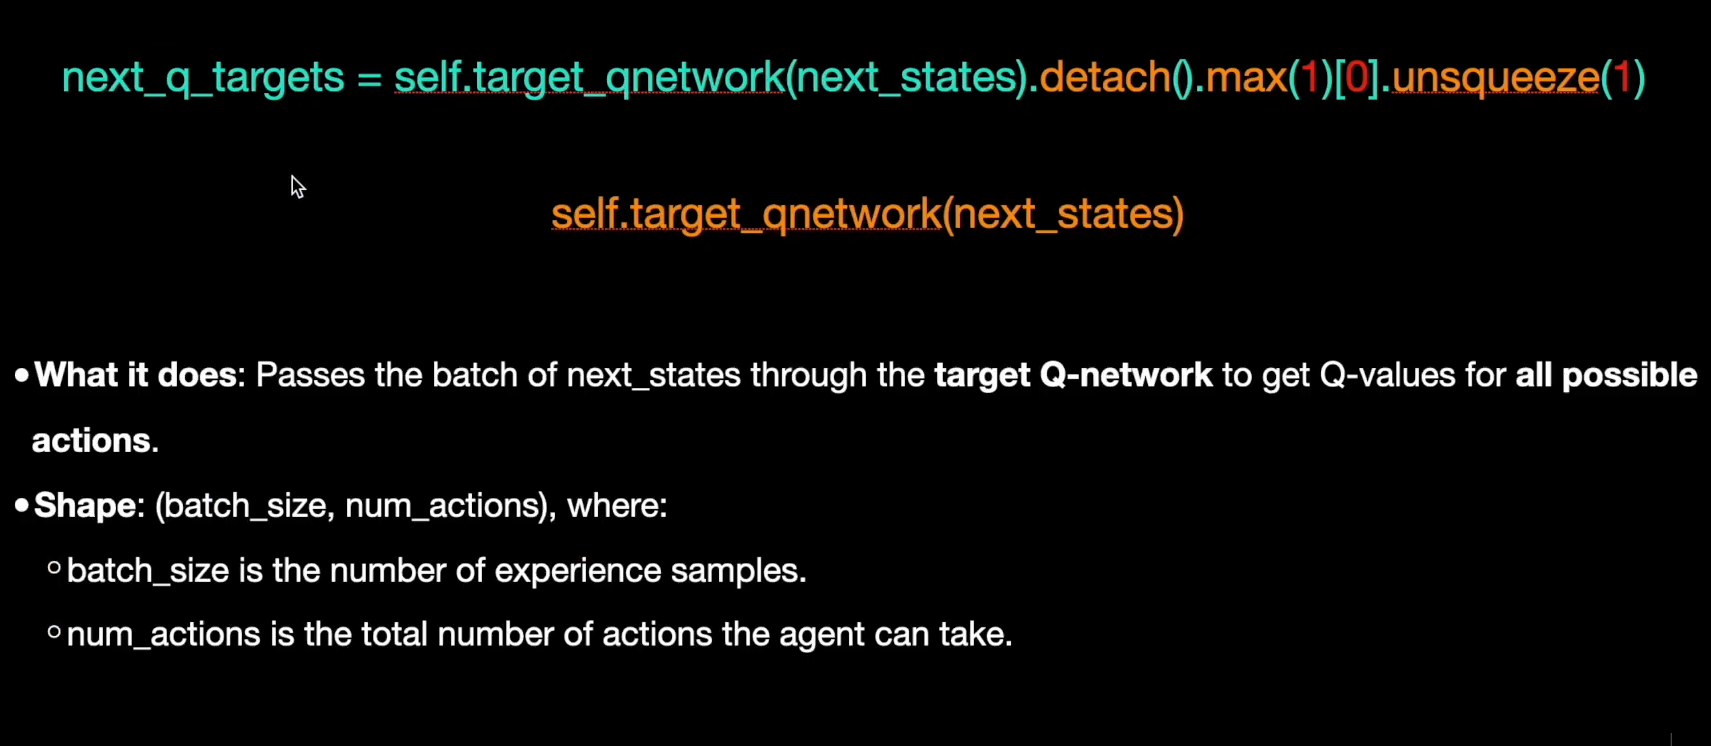

- ## Detach() method.
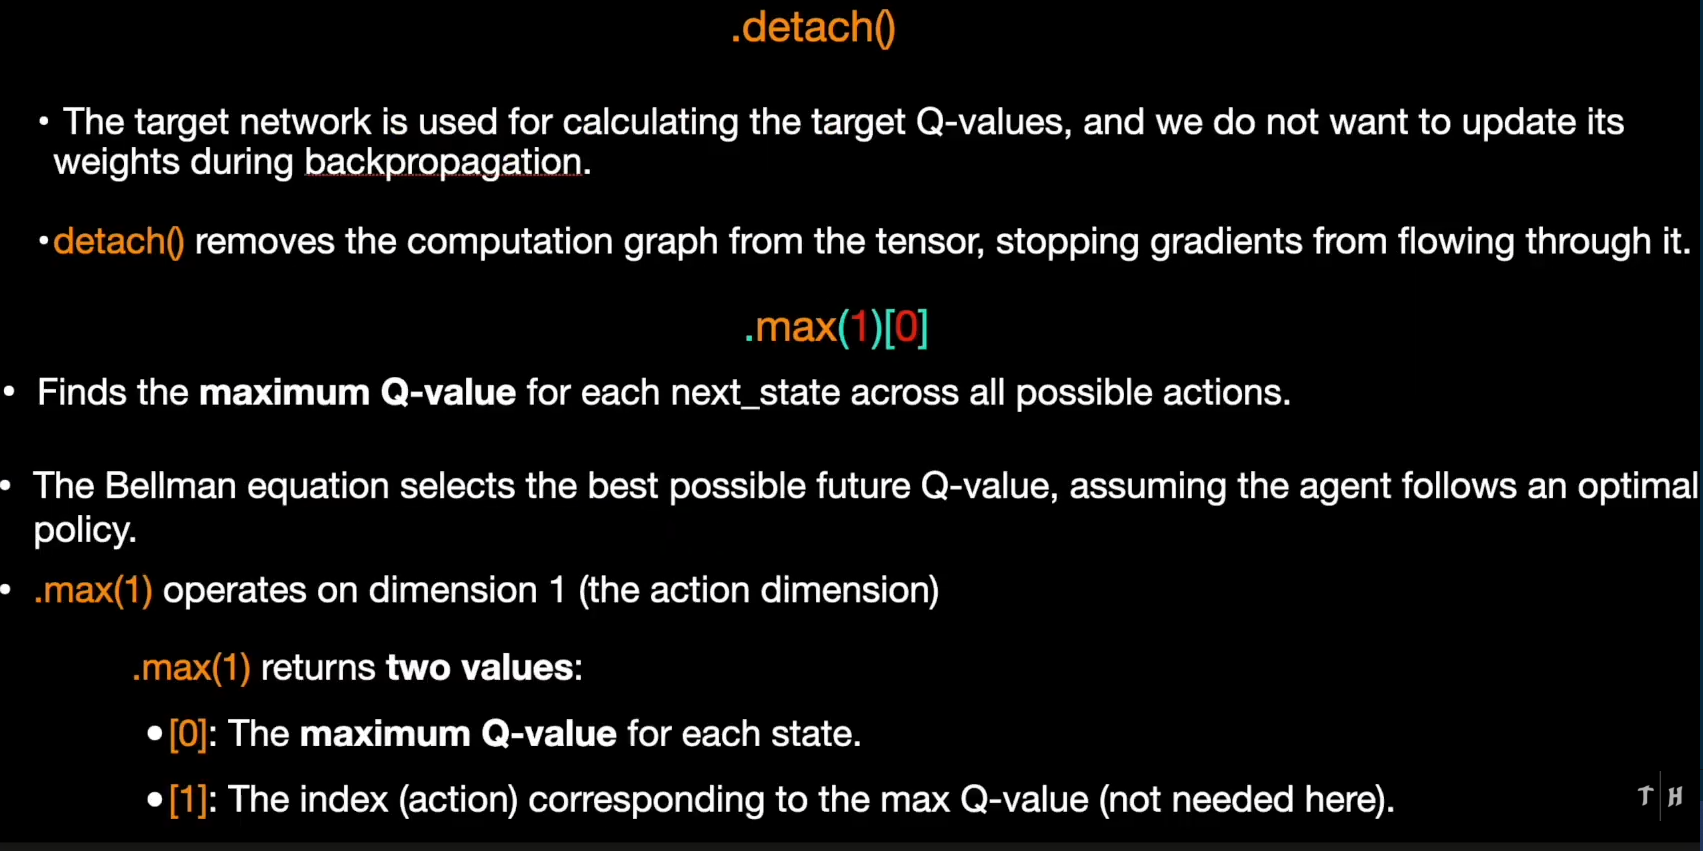

- ## Unsqueeze() method.
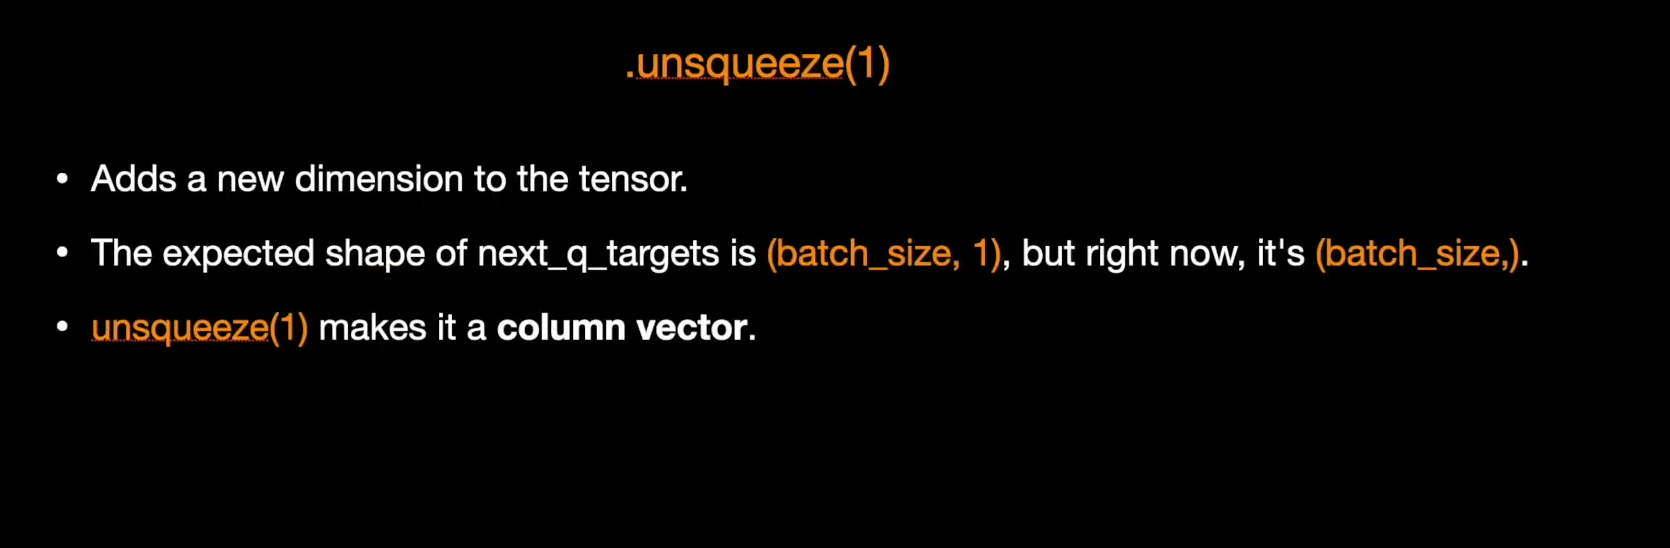

- ## Example for the Next-Q-Targets.
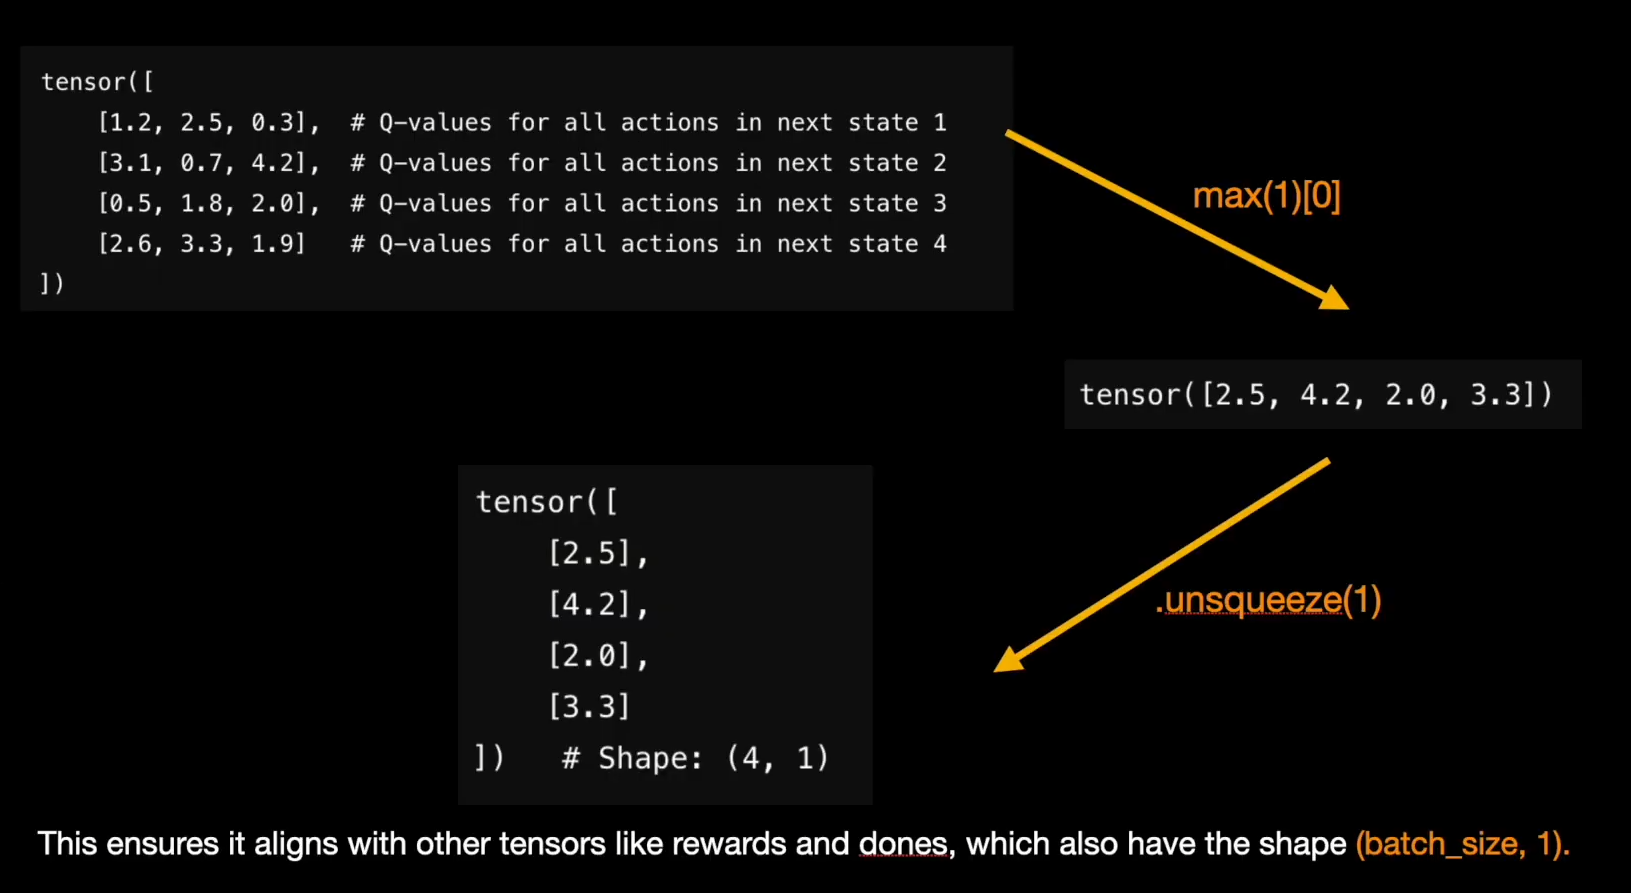

In [ ]:
class Agent():

        def __init__(self, state_size, action_size):
                self.state_size = state_size
                self.action_size = action_size
                self.local_qnetwork = ANN(state_size, action_size)
                self.target_qnetwork = ANN(state_size, action_size)
                self.optimizer = optim.Adam(self.local_qnetwork.parameters(), lr = learning_rate)
                self.memory = ReplayMemory(replay_buffer_size)
                self.t_step = 0

        def set(self, state, action, reward, next_state, done):
                self.memory.push((state, action, reward, next_state, done))
                self.t_step = (self.t_step+1) % 4
                if self.t_step == 0:
                        if len(self.memory.memory) > minibatch:
                                experiences = self.memory.memory(minibatch)
                                self.learn(experiences, gamma)

        def get_action(self, state, epsilon):
                states = torch.from_numpy(state).float().unsqueeze(0)
                self.local_qnetwork.eval()
                with torch.no_grad():
                        action_values = self.local_qnetwork(state)  # [Q(sate, action[0]), Q(state, action_1), ..... ]

                self.local_qnetwork.train()
                if random.random() > epsilon:
                        return np.argmax(action_values.cpu().data.numpy())
                else:
                        return random.choice(np.arange(self.action_size))

        def learn(self, experiences, gamma):
                states, actions, rewards, next_states, dones = experiences
                next_q_targets = self.target_qnetwork(next_states).detach().max(1)[0].unsqueeze(1)
